CNICA completed in 0.50 seconds.
RMSE of Initial CNICA vs True: 0.027643887285239872


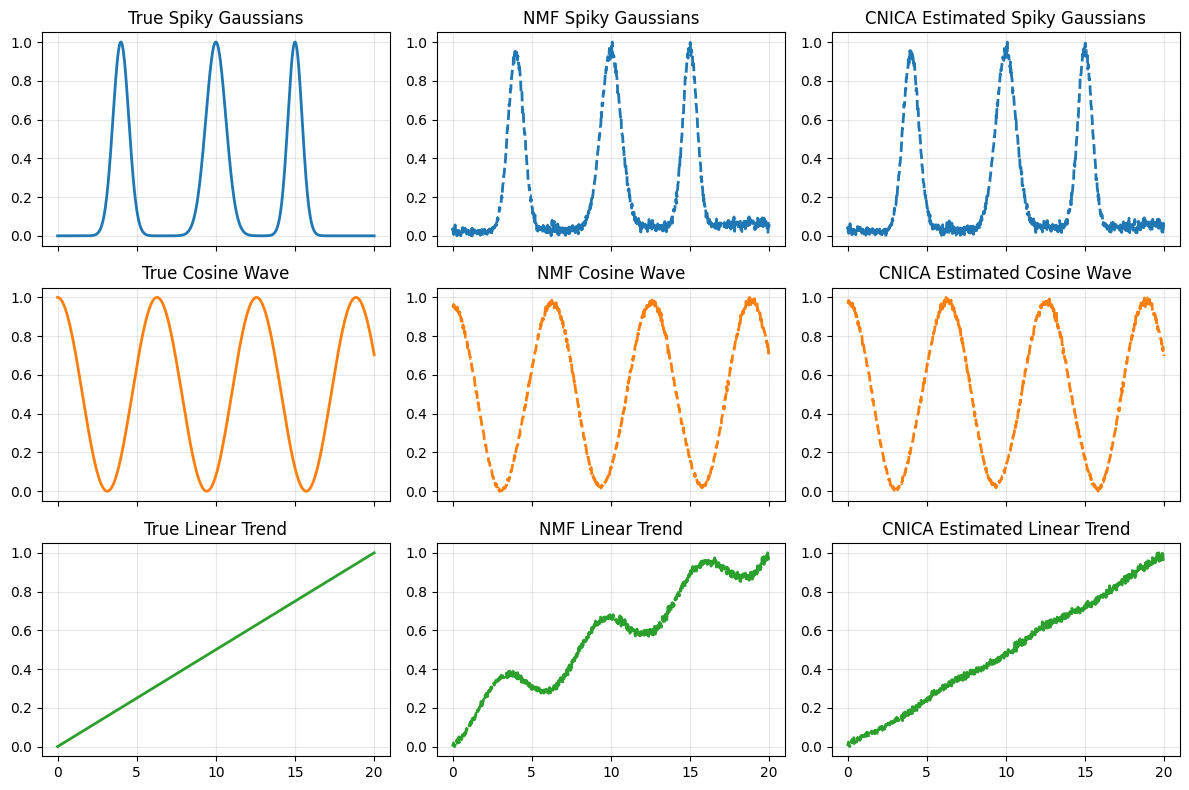

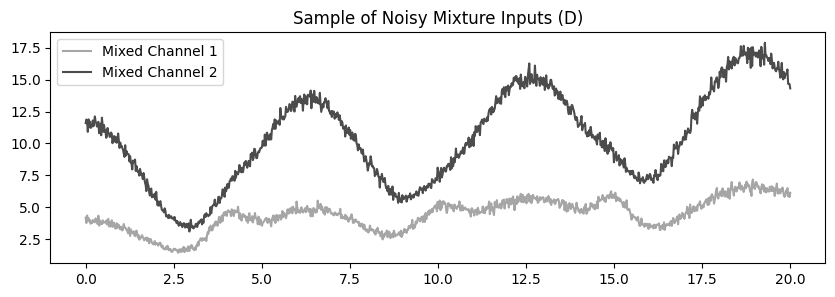

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from core import CNICA
from models import NMFParams, MIOParams
from time import time

# 1. Setup Dimensions
n_wave = 1000
n_channels = 100
n_components = 3
x = np.linspace(0, 20, n_wave)

# 2. Create Ground Truth Sources (S) - Shape: (3, 1000)
# S1: Spiky Gaussians
s1 = np.exp(-(x-4)**2/0.5) + np.exp(-(x-10)**2/0.8) + np.exp(-(x-15)**2/0.4)
# S2: Cosine (shifted positive)
s2 = np.cos(x) + 1.2
# S3: Linear (shifted positive)
s3 = 0.1 * x + 0.5

S_true = np.vstack([s1, s2, s3])

# 3. Create Positive Mixing Matrix (C) - Shape: (100, 3)
# Using a Dirichlet or high-variance random to ensure diverse mixtures
np.random.seed(42)
C_true = np.random.gamma(shape=2.0, scale=1.0, size=(n_channels, n_components))

# 4. Generate Data Matrix D = C @ S (100 x 1000)
# Note: Using C @ S to match (channels x samples) convention
D_clean = C_true @ S_true

# 5. Add Poissonian Noise
# Poisson noise is proportional to signal intensity
noise_scale = 100  # Increase to make signals larger/noise relatively smaller
D_noisy = np.random.poisson(D_clean * noise_scale) / noise_scale

# 6. Run CNICA
# We use Kullback-Leibler for NMF as it's better for Poisson noise
t0 = time()
model = CNICA(
    n_components=n_components, 
    nmf_params=NMFParams(max_iter=20000, tol=1e-4),
    mio_params=MIOParams(max_outer_loop_iters=5, tol=1.0, max_inner_loop_iters=1000, initial_lr=0.1)
)
S_est = model.fit_transform(D_noisy) # type: ignore[no-untyped-call]
t1 = time()
print(f"CNICA completed in {t1 - t0:.2f} seconds.")

# 7. Post-Processing for Visualization (Permutation & Scaling Ambiguity)
# ICA/NMF can return components in any order and any scale.
# We normalize to [0, 1] for visual comparison.
scaler = MinMaxScaler()
S_true_norm = scaler.fit_transform(S_true.T).T # type: ignore[no-untyped-call]
S_est_norm = scaler.fit_transform(S_est.T).T # type: ignore[no-untyped-call]
S_initial = scaler.fit_transform(model.S_initial_.T).T # type: ignore[no-untyped-call]

# Greedy re-ordering to match Estimated to True
reordered_est = np.zeros_like(S_est_norm)
for i in range(n_components):
    corrs = [np.corrcoef(S_true_norm[i], S_est_norm[j])[0, 1] for j in range(n_components)]
    best_match = np.argmax(corrs)
    reordered_est[i] = S_est_norm[best_match]

# Greedy re-ordering to match Estimated to True
reordered_initial = np.zeros_like(S_initial)
for i in range(n_components):
    corrs = [np.corrcoef(S_true_norm[i], S_initial[j])[0, 1] for j in range(n_components)]
    best_match = np.argmax(corrs)
    reordered_initial[i] = S_initial[best_match]

print('RMSE of Initial CNICA vs True:', np.sqrt(np.mean((S_true_norm - reordered_est) ** 2)))

# 8. Plotting
fig, axes = plt.subplots(n_components, 3, figsize=(12, 8), sharex=True) # type: ignore
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
names = ['Spiky Gaussians', 'Cosine Wave', 'Linear Trend']

for i in range(n_components):
    # True Sources
    axes[i, 0].plot(x, S_true_norm[i], color=colors[i], lw=2)
    axes[i, 0].set_title(f"True {names[i]}")
    axes[i, 0].grid(alpha=0.3)
    
    # Initial Sources
    axes[i, 1].plot(x, reordered_initial[i], color=colors[i], linestyle='--', lw=2)
    axes[i, 1].set_title(f"NMF {names[i]}")
    axes[i, 1].grid(alpha=0.3)

    # Estimated Sources
    axes[i, 2].plot(x, reordered_est[i], color=colors[i], linestyle='--', lw=2)
    axes[i, 2].set_title(f"CNICA Estimated {names[i]}")
    axes[i, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show() # type: ignore

# Mix Plot (The Raw Data the model sees)
plt.figure(figsize=(10, 3)) # type: ignore
plt.plot(x, D_noisy[0], color='gray', alpha=0.7, label='Mixed Channel 1') # type: ignore
plt.plot(x, D_noisy[1], color='black', alpha=0.7, label='Mixed Channel 2') # type: ignore
plt.title("Sample of Noisy Mixture Inputs (D)") # type: ignore
plt.legend() # type: ignore

(3, 1000)
(3, 100)


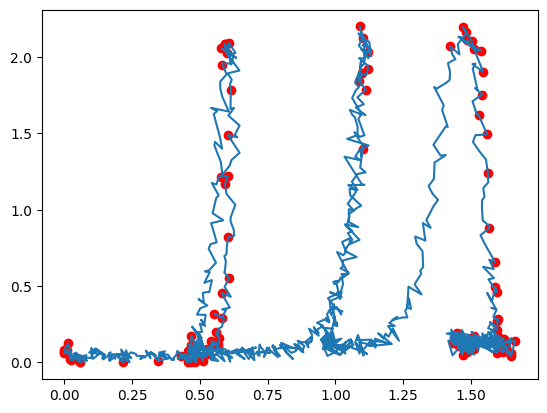

In [35]:
from optimizer import MIOptimizer


C_initial = model.C_initial_
S_initial = model.S_initial_

mio = MIOptimizer(max_outer_loop_iters=5, 
                tol=0.00001, 
                max_inner_loop_iters=1000, 
                gamma=0.03, 
                initial_lr=0.1)

#mio.fit_transform(model.C_initial_, S_initial)
print(mio.prune(S_initial, gamma=0.02).shape)
S_const = mio.extract_boundary(S_initial)
print(mio.prune(C_initial, gamma=0.02).shape)
C_const = mio.extract_boundary(C_initial)



plt.plot(S_initial[1], S_initial[2])
plt.scatter(S_const[1], S_const[2], color='red')

In [6]:
model.mio_result_.MS.shape

(3, 1000)

In [3]:
model = CNICA(
    n_components=n_components, 
    nmf_params=NMFParams(max_iter=20000, tol=1e-5),
    mio_params=MIOParams(max_outer_loop_iters=5, tol=1e-6, max_inner_loop_iters=1000)
)

S_est = model.fit_transform(D_noisy)

  Inner iteration 100, inner iteration = 99,  f=-226.6946, ||grad||=1.9039e+00
  Inner iteration 200, inner iteration = 199,  f=-226.6946, ||grad||=1.9039e+00
  Inner iteration 300, inner iteration = 299,  f=-226.6946, ||grad||=1.9039e+00
  Inner iteration 400, inner iteration = 399,  f=-226.6946, ||grad||=1.9038e+00
  Inner iteration 500, inner iteration = 499,  f=-226.6946, ||grad||=1.9038e+00
  Inner iteration 600, inner iteration = 599,  f=-226.6946, ||grad||=1.9038e+00
  Inner iteration 700, inner iteration = 699,  f=-226.6946, ||grad||=1.9038e+00
  Inner iteration 800, inner iteration = 799,  f=-226.6946, ||grad||=1.9038e+00
  Inner iteration 900, inner iteration = 899,  f=-226.6946, ||grad||=1.9038e+00
  Inner iteration 1000, inner iteration = 999,  f=-226.6946, ||grad||=1.9038e+00


In [2]:
from scipy.optimize import approx_fprime
from optimizer import MIOptimizer



res = MIOptimizer.left_barrier(np.eye(3), C_true.T, 1.0, compute_grad=True)
grad_analytical = res.grad # type: ignore


def f_wrapper(m_flat: np.ndarray) -> float:
    M_reshaped = m_flat.reshape(3, 3)
    inv_M_reshaped = np.linalg.inv(M_reshaped)
    return MIOptimizer.left_barrier(inv_M_reshaped, C_true.T, 1.0, compute_grad=False).f

grad_numerical = approx_fprime(np.eye(3).flatten(), f_wrapper, epsilon=1e-7).reshape(3, 3)

print(grad_analytical)
print(grad_numerical)

[[ 99.99999905 159.76473926 166.32735782]
 [182.73735699  99.99999924 198.65708946]
 [153.37820313 137.07126633  99.99999909]]
[[ 99.999994   159.76476988 166.32738493]
 [182.7373984   99.999994   198.65716695]
 [153.37823584 137.07128801  99.999994  ]]


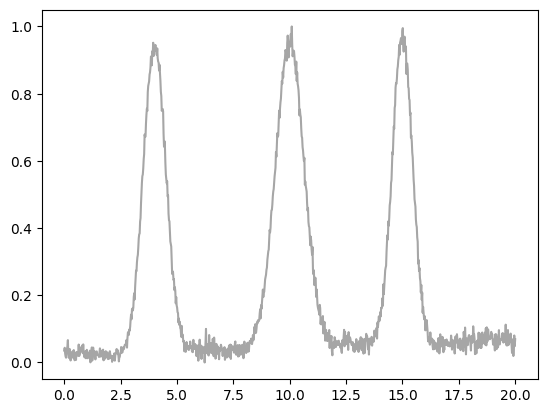

In [ ]:
plt.plot(x, S_initial[2], color='gray', alpha=0.7, label='Initial Component 1') # type: ignore

In [4]:
import numpy as np

def calculate_sparsity_weights(
    S_init: np.ndarray, 
    base_lambda: float = 0.05, 
    threshold: float = 0.25
) -> np.ndarray:
    """
    Classifies rows as 'dense' or 'sparse' using Hoyer's metric
    and returns an array of lambda weights.
    """
    n_components, w = S_init.shape
    lambdas = np.zeros(n_components)
    
    # Precompute sqrt(w)
    sqrt_w = np.sqrt(w)
    
    for i in range(n_components):
        row = S_true[i, :]
        
        # Calculate L1 and L2 (safe for non-negative S)
        l1 = np.sum(row)
        l2 = np.sqrt(np.sum(row**2)) + 1e-16
        
        # Hoyer's Sparsity Measure (0 to 1)
        hoyer_score = ((l1 / l2) - 1) / (sqrt_w - 1)

        print(f"Component {i} Hoyer Score: {hoyer_score:.3f}")

        k = 30.0
        beta = 0.5
        lam = 1.0
        diff = k * (beta - hoyer_score)
        exp_diff = np.exp(diff)
        f = -(lam / k) * np.sum(np.log(1.0 + exp_diff))
        print(f"    Sparsity Penalty f: {f:.4f}")
        
        # If it's somewhat sparse, turn on the cleaner
        if hoyer_score > threshold:
            lambdas[i] = base_lambda
            print(f" -> Classified as SPARSE. Lambda = {base_lambda}")
        else:
            print(f" -> Classified as DENSE. Lambda = 0.0")
            
    return lambdas


calculate_sparsity_weights(
    S_true_norm, 
    base_lambda=1.0, 
    threshold=0.25
)


Component 0 Hoyer Score: 0.513
    Sparsity Penalty f: -0.0170
 -> Classified as SPARSE. Lambda = 1.0
Component 1 Hoyer Score: 0.864
    Sparsity Penalty f: -0.0000
 -> Classified as SPARSE. Lambda = 1.0
Component 2 Hoyer Score: 0.931
    Sparsity Penalty f: -0.0000
 -> Classified as SPARSE. Lambda = 1.0


array([1., 1., 1.])